<a href="https://colab.research.google.com/github/shail-bit/CO2-Emissions-Prediction-Model/blob/main/CO2_emission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
data = pd.read_csv ('CO2 Emissions_Canada.csv')
print(data.head())

    Make       Model Vehicle Class  Engine Size(L)  Cylinders Transmission  \
0  ACURA         ILX       COMPACT             2.0          4          AS5   
1  ACURA         ILX       COMPACT             2.4          4           M6   
2  ACURA  ILX HYBRID       COMPACT             1.5          4          AV7   
3  ACURA     MDX 4WD   SUV - SMALL             3.5          6          AS6   
4  ACURA     RDX AWD   SUV - SMALL             3.5          6          AS6   

  Fuel Type  Fuel Consumption City (L/100 km)  \
0         Z                               9.9   
1         Z                              11.2   
2         Z                               6.0   
3         Z                              12.7   
4         Z                              12.1   

   Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  \
0                              6.7                               8.5   
1                              7.7                               9.6   
2                   

In [24]:
numerical_features = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)','Fuel Consumption Hwy (L/100 km)','Fuel Consumption Comb (L/100 km)','Fuel Consumption Comb (mpg)']

print(data[numerical_features + ['CO2 Emissions(g/km)']].describe())

       Engine Size(L)    Cylinders  Fuel Consumption City (L/100 km)  \
count     7385.000000  7385.000000                       7385.000000   
mean         3.160068     5.615030                         12.556534   
std          1.354170     1.828307                          3.500274   
min          0.900000     3.000000                          4.200000   
25%          2.000000     4.000000                         10.100000   
50%          3.000000     6.000000                         12.100000   
75%          3.700000     6.000000                         14.600000   
max          8.400000    16.000000                         30.600000   

       Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  \
count                      7385.000000                       7385.000000   
mean                          9.041706                         10.975071   
std                           2.224456                          2.892506   
min                           4.000000         

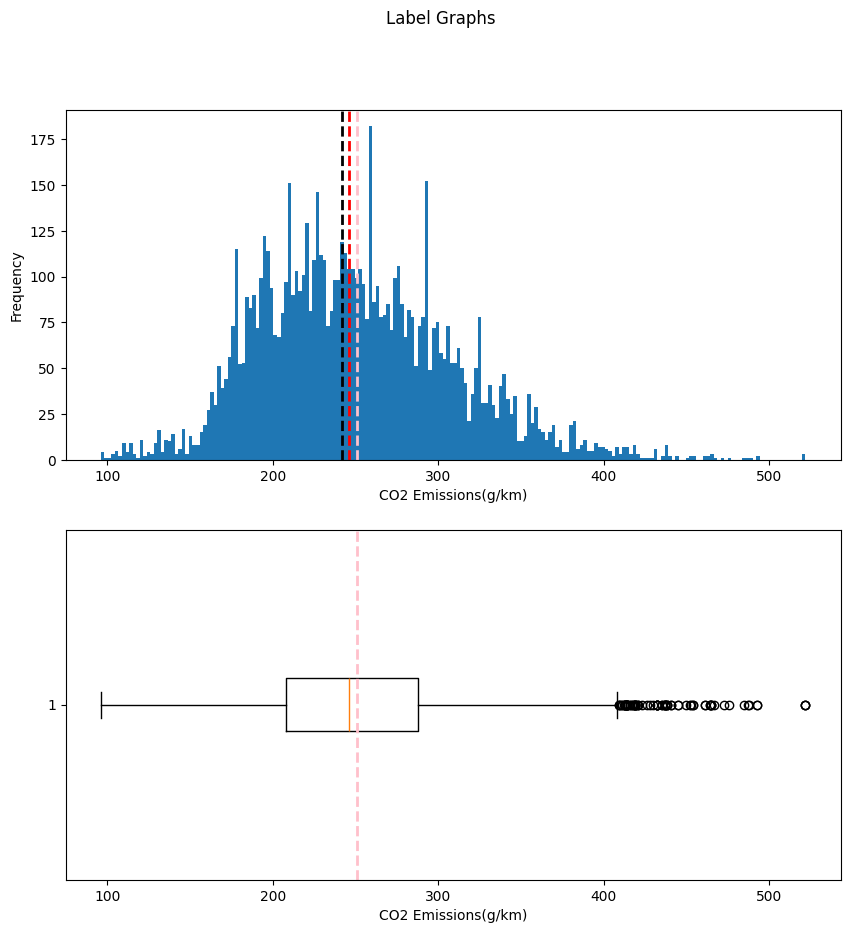

In [36]:
# visualizing the labelled data
import matplotlib.pyplot as plt
label = data['CO2 Emissions(g/km)']

fig , ax = plt.subplots( 2,1, figsize=(10,10))

ax[0].hist(label, bins=200)
ax[0].set_ylabel("Frequency")
ax[0].set_xlabel("CO2 Emissions(g/km)")
ax[0].axvline(label.mean(), color = 'pink', linewidth = 2, linestyle = 'dashed')
ax[0].axvline(label.median(), color = 'red', linewidth = 2, linestyle = 'dashed')
mode_value = label.mode()[0]
ax[0].axvline(mode_value, color = 'black', linewidth = 2, linestyle = 'dashed')

ax[1].boxplot(label , vert= False)
ax[1].set_xlabel("CO2 Emissions(g/km)")
ax[1].axvline(label.mean(), color = 'pink', linewidth = 2, linestyle = 'dashed')
fig.suptitle("Label Graphs")
plt.show()


After visualization of the CO2 emission, we can see that our data is very close to being normally distributed (by the histogram), and by the boxplot we can see that a lot of the data is near the median, and they are many outliers (emissions were very high).

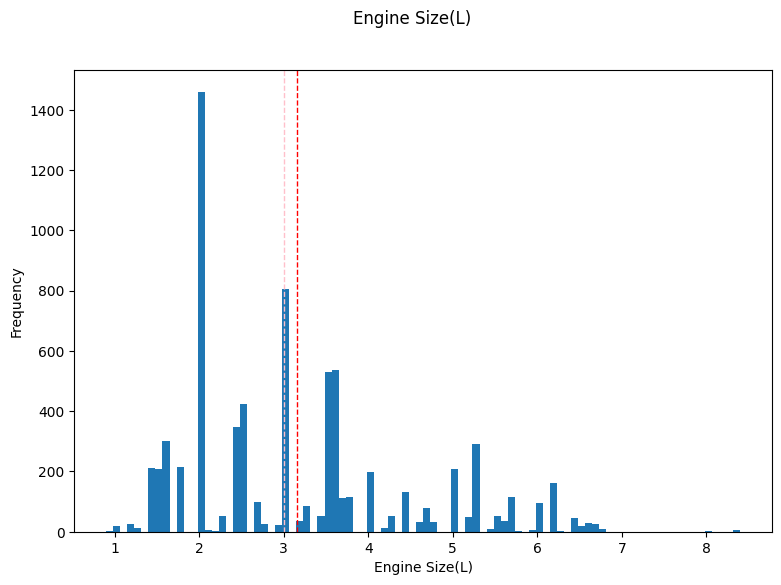

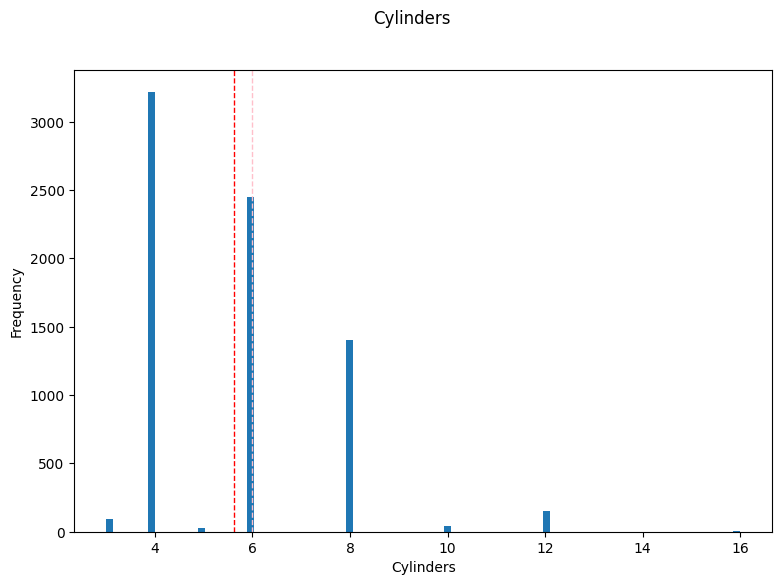

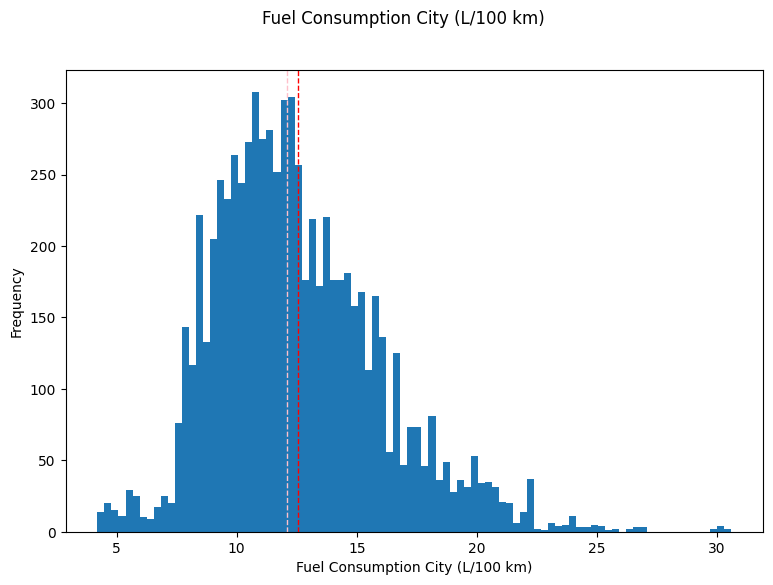

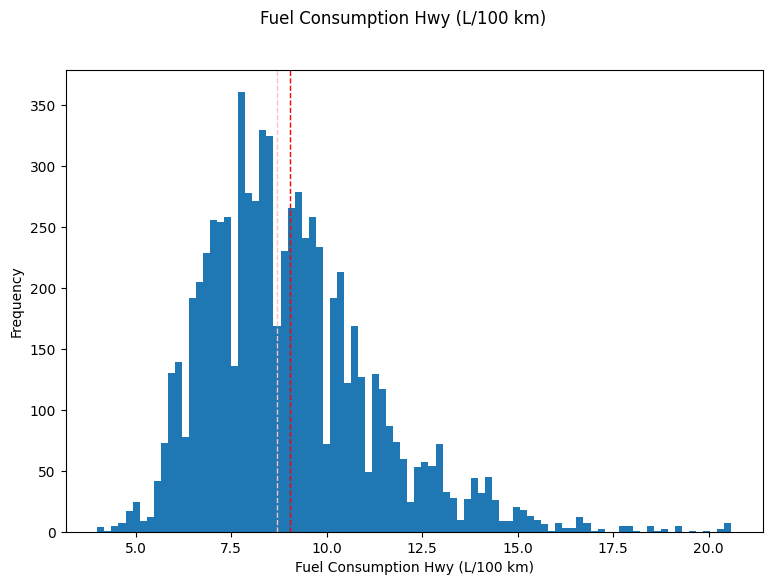

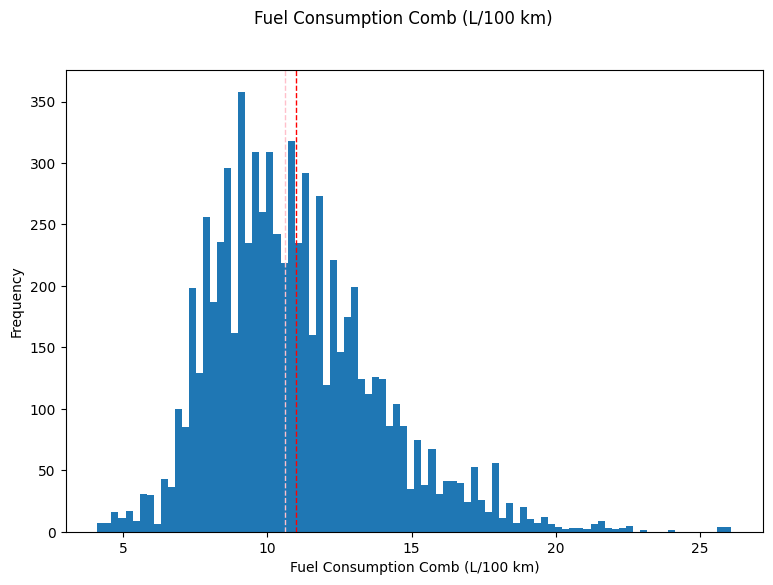

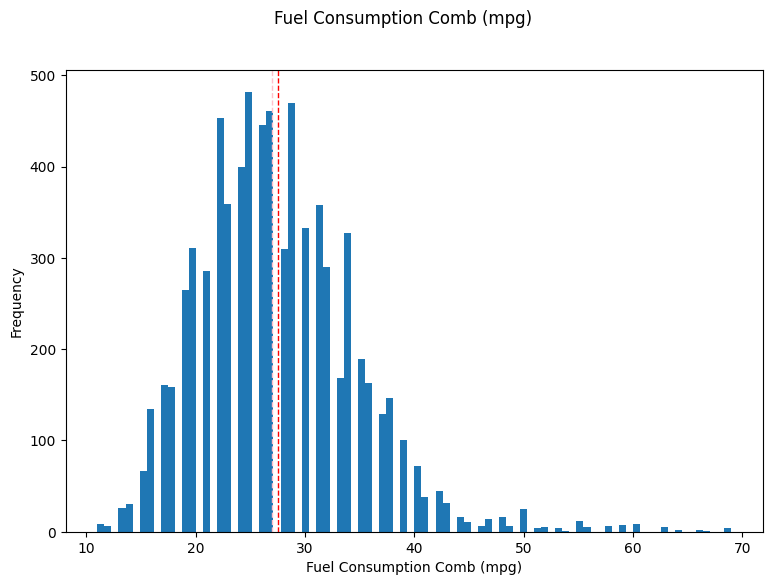

In [49]:
from matplotlib.lines import lineStyles
#visualizing the numerical features

for col in numerical_features:
  fig = plt.figure(figsize =(9,6))
  ax = fig.gca()

  ax.hist(data[col] ,bins = 90)
  ax.axvline(data[col].mean(), color = 'red', linestyle = 'dashed', linewidth = 1)
  ax.axvline(data[col].median(), color = 'pink', linestyle = 'dashed', linewidth = 1)
  ax.set_xlabel(col)
  ax.set_ylabel('Frequency')
  fig.suptitle(col)
  fig.show()

This shows that most of the numerical features are normally distributed except for engine size and cylinders.

['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type']


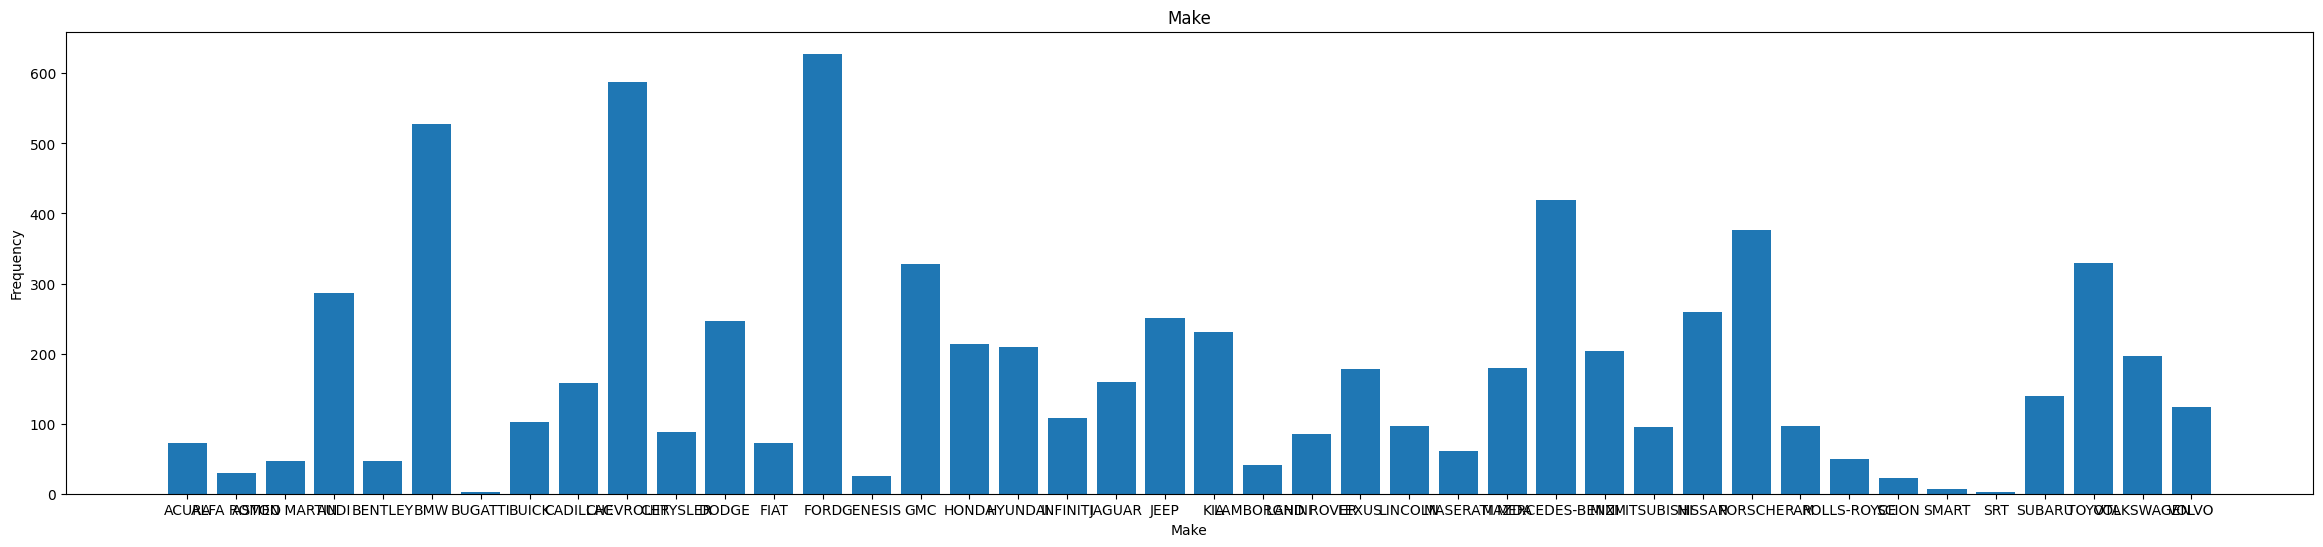

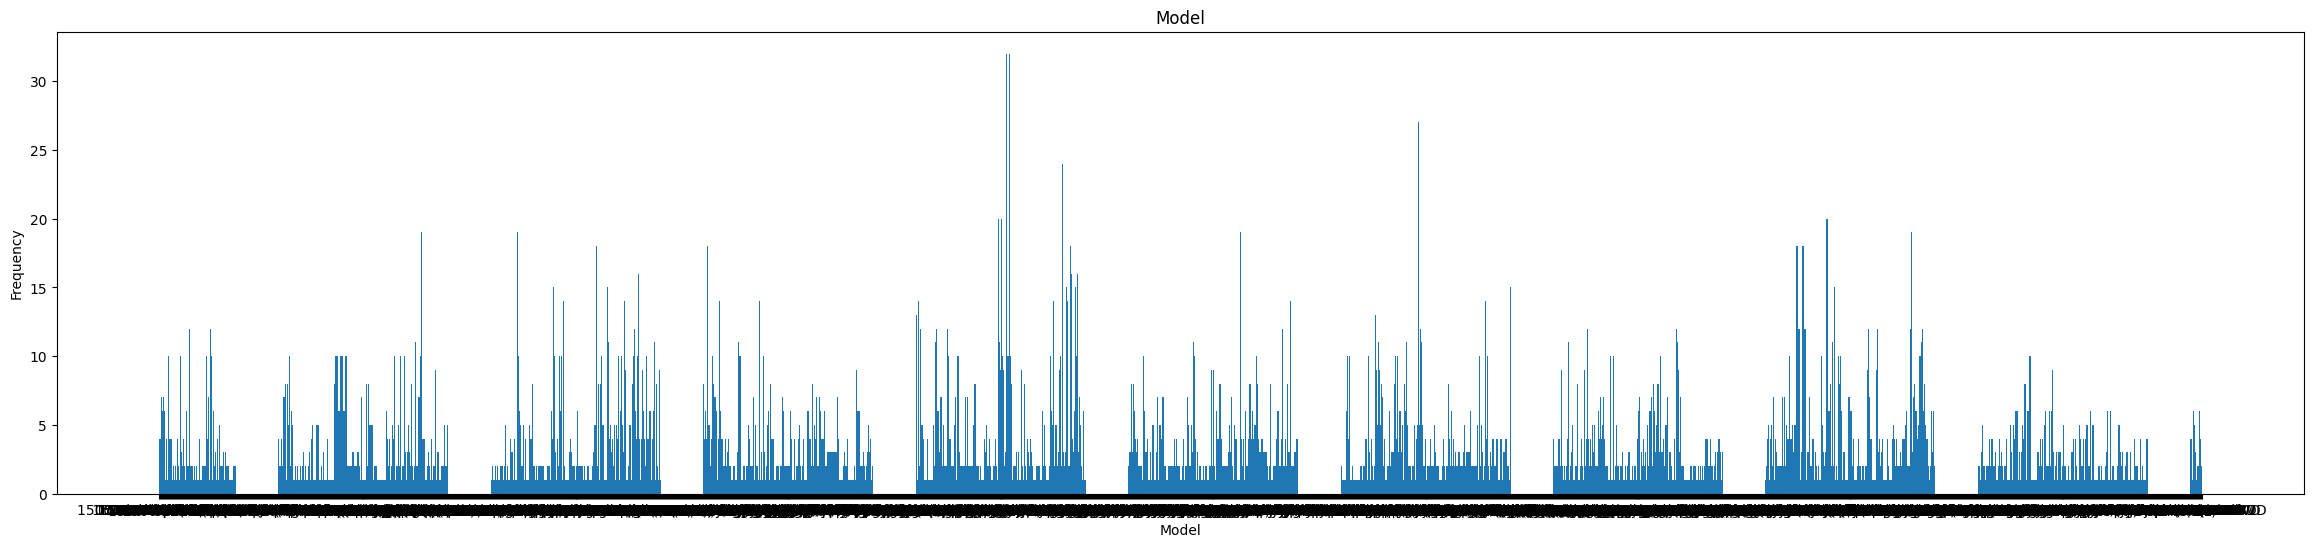

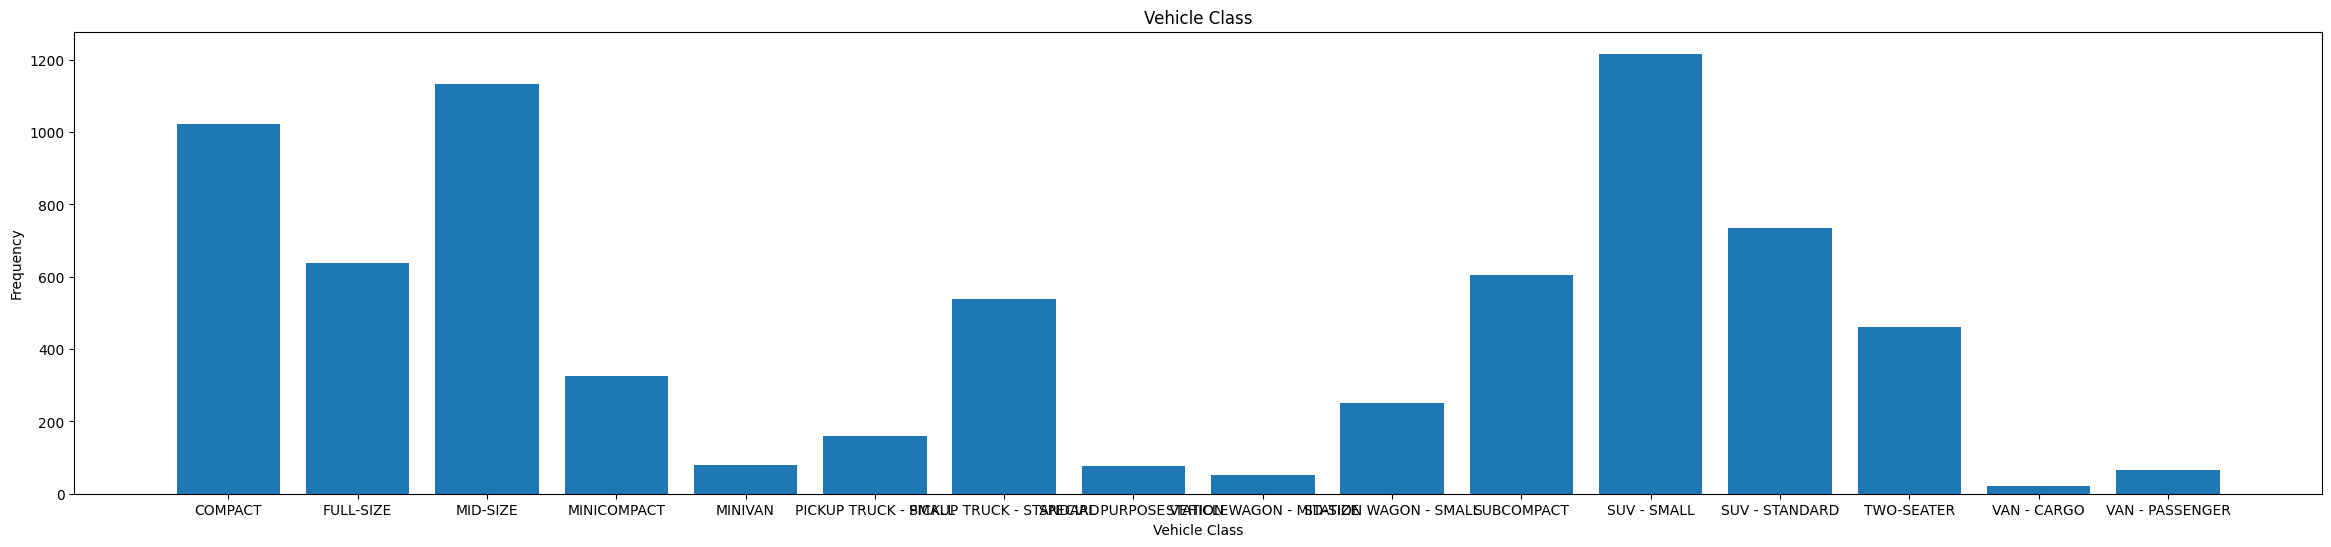

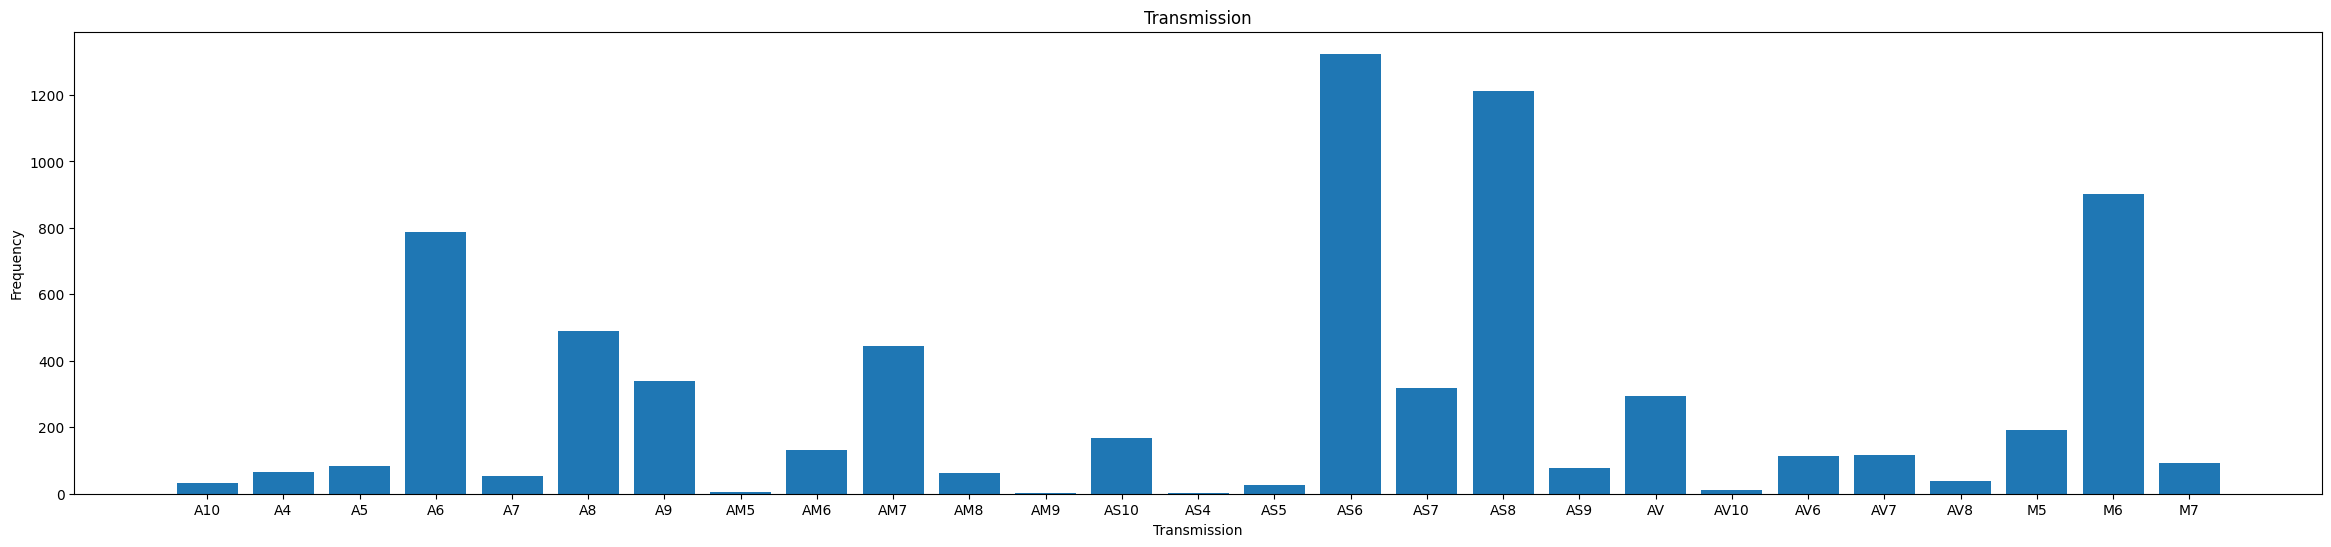

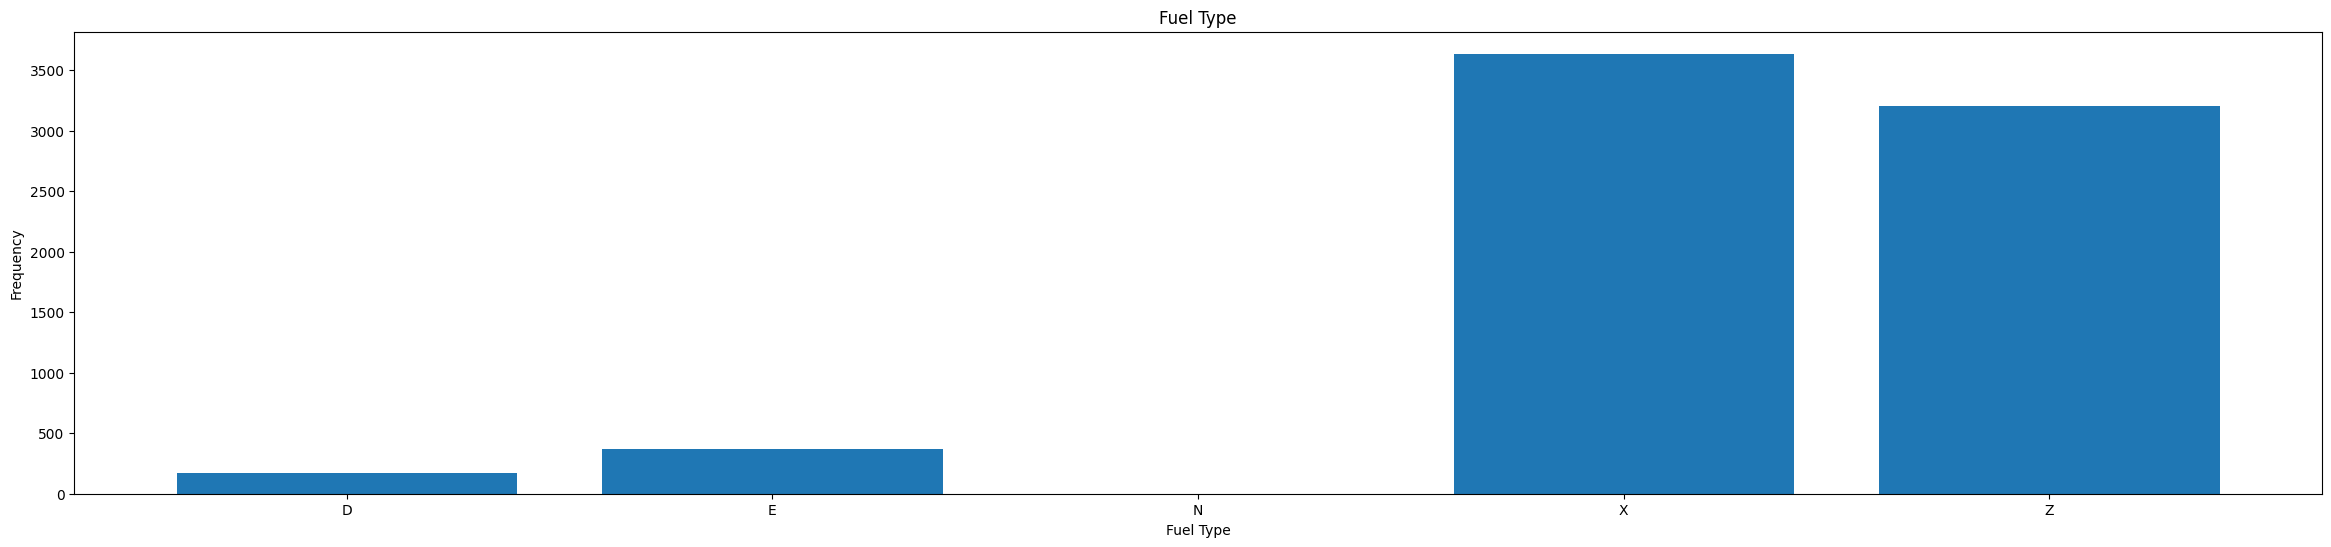

In [63]:
#visualizing categorical features
categorical_features = ['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type']
print(categorical_features)


for col in categorical_features:
  fig = plt.figure(figsize = (29,6))
  ax=fig.gca()

  count = data[col].value_counts().sort_index()

  ax.bar(count.index, count.values)
  ax.set_ylabel("Frequency")
  ax.set_xlabel(col)
  ax.set_title(col)
  fig.show()

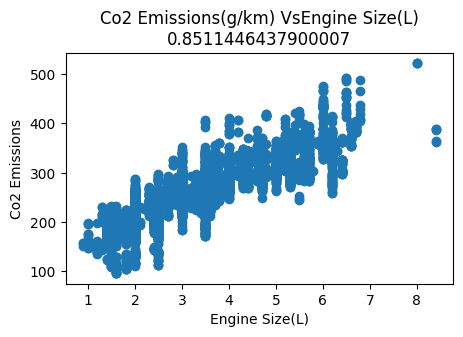

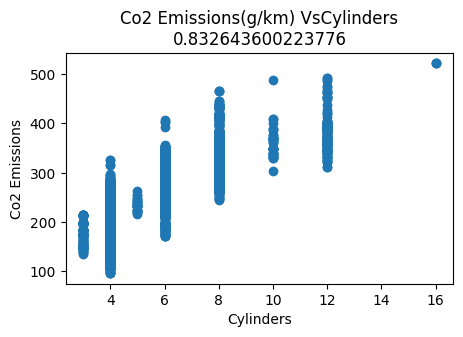

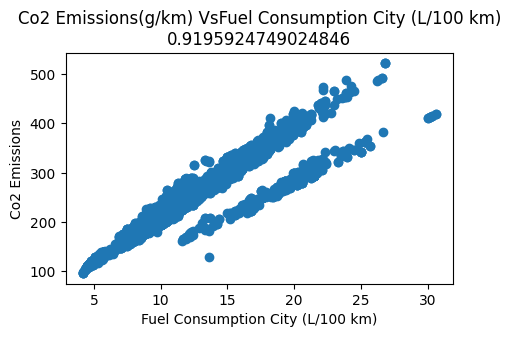

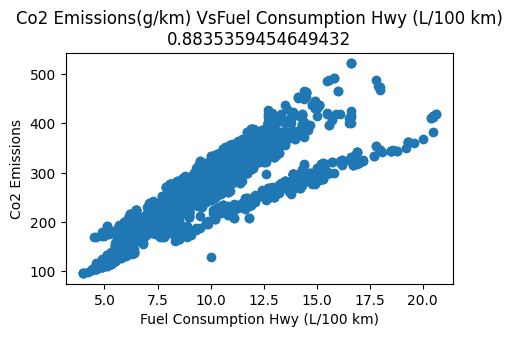

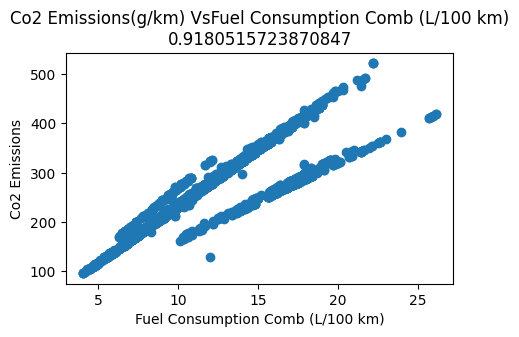

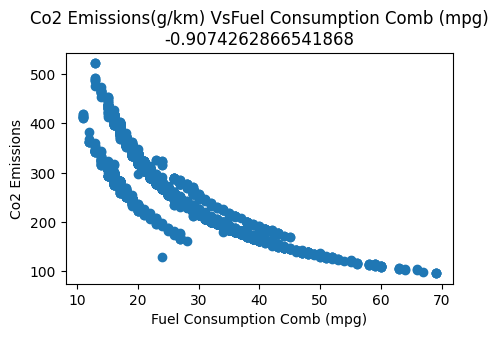

In [67]:
#finding correlation between numerical features and labels

for col in numerical_features:
  fig = plt.figure(figsize=(5,3))
  ax= fig.gca()

  ax.scatter(x=data[col], y=label)
  correlation = data[col].corr(label)
  ax.set_xlabel(col)
  ax.set_ylabel('Co2 Emissions')
  ax.set_title('Co2 Emissions(g/km) Vs'+ col + '\n'+ str(correlation))
fig.show()


A diagonal scatter plot shows the direct prortionality between the numerical features and the label, whereas the last plot shows inverse prortionality.

In [72]:
y = data['CO2 Emissions(g/km)'].values
x = data[numerical_features].values

print('Features', x[:10], '\n Labels:', y[:10], sep='\n')

Features
[[ 2.   4.   9.9  6.7  8.5 33. ]
 [ 2.4  4.  11.2  7.7  9.6 29. ]
 [ 1.5  4.   6.   5.8  5.9 48. ]
 [ 3.5  6.  12.7  9.1 11.1 25. ]
 [ 3.5  6.  12.1  8.7 10.6 27. ]
 [ 3.5  6.  11.9  7.7 10.  28. ]
 [ 3.5  6.  11.8  8.1 10.1 28. ]
 [ 3.7  6.  12.8  9.  11.1 25. ]
 [ 3.7  6.  13.4  9.5 11.6 24. ]
 [ 2.4  4.  10.6  7.5  9.2 31. ]]

 Labels:
[196 221 136 255 244 230 232 255 267 212]


We have our independant variables in x and our dependent variable y. Now we will use regression model. First, we will train the model and then test it.

In [79]:
#dividing the data into training and testing set
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, test_size=0.3, random_state=0)
print("Training set %d rows \n Testing Set %d rows" % (x_train.shape[0], x_test.shape[0]))

Training set 5169 rows 
 Testing Set 2216 rows


In [84]:
#regression
from sklearn.linear_model import LinearRegression

model= LinearRegression().fit(x_train, y_train)
print(model)
print(model.coef_)
print(model.intercept_)

LinearRegression()
[ 4.71463589  7.8064655  -1.59915618  2.75835568  4.8279366  -3.42735643]
228.1354870677328


From this we get our coefficient values and intercept values for our regression model. Now we will predict some of our labels using the testing set.

In [85]:
import numpy as np

predictions = model.predict(x_test)
np.set_printoptions(suppress = True)

print('Printed Labels', np.round(predictions)[:10])
print("Actual Labels", y_test[:10])

Printed Labels [250. 204. 262. 189. 243. 255. 288. 271. 203. 258.]
Actual Labels [241 229 253 183 231 195 301 277 201 280]


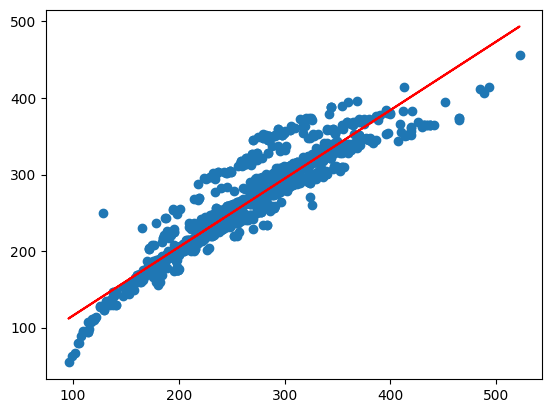

In [89]:
plt.scatter(x = y_test, y = predictions)
z = np.polyfit(y_test, predictions, 1)
p = np.poly1d(z)


plt.plot(y_test, p(y_test), color = 'red')

plt.show()

We have formed our regression line, and now we will find the errors.

In [92]:
from sklearn.metrics import mean_squared_error,r2_score

mse = mean_squared_error(y_test,predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,predictions)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 359.04059419027294
RMSE: 18.948366530924847
R2 Score: 0.894263189401499


CONCLUSION:

In this project, a Linear Regression model was built to predict CO2 emissions of vehicles using the Canada CO2 Emissions dataset. The dataset contained various vehicle features such as engine size, number of cylinders, and fuel consumption, out of which numerical features were selected for training the model.
The data was split into 70% training and 30% testing set. After training the model, the following results were obtained:

MSE: 359.04 — on average, the squared difference between actual and predicted CO2 values.

RMSE: 18.95 — the model's predictions are off by approximately 18.95 g/km on average.

R² Score: 0.894 — the model explains about 89.4% of the variance in CO2 emissions, which indicates a strong fit

The R² score of 0.89 suggests that the linear regression model performed well on this dataset. The strong correlation between fuel consumption and CO2 emissions was the key factor driving the model's accuracy.
However, the model can be further improved by including categorical features like Fuel Type and Vehicle Class after encoding them, which were not used in this version.
